# Chapter 4 — Windowing & Spectral Leakage

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch04_windowing_leakage.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch04_windowing_leakage.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch04_windowing_leakage.ipynb)

> **Motivating question.** Why does a clean sinusoid smear across neighbouring frequencies, and which window fixes it?

## What this notebook demonstrates

- The finite-length problem and the origin of spectral leakage
- Window functions (rect, Hann, Hamming, Blackman, Kaiser, Tukey)
- Main-lobe width, side-lobe level, ENBW, scalloping loss
- The resolution–leakage trade-off, quantified
- Choosing a window for ECG / EEG / EMG

## What you'll do

You'll compare five window functions on the same two-tone signal, measure their main-lobe/side-lobe trade-off directly, and sweep a Kaiser window's β to watch resolution and leakage move in opposite directions.

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | full (synthetic data, NumPy/SciPy/sklearn only) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from scipy import signal as sig

CH = 4

## 4.1  windows

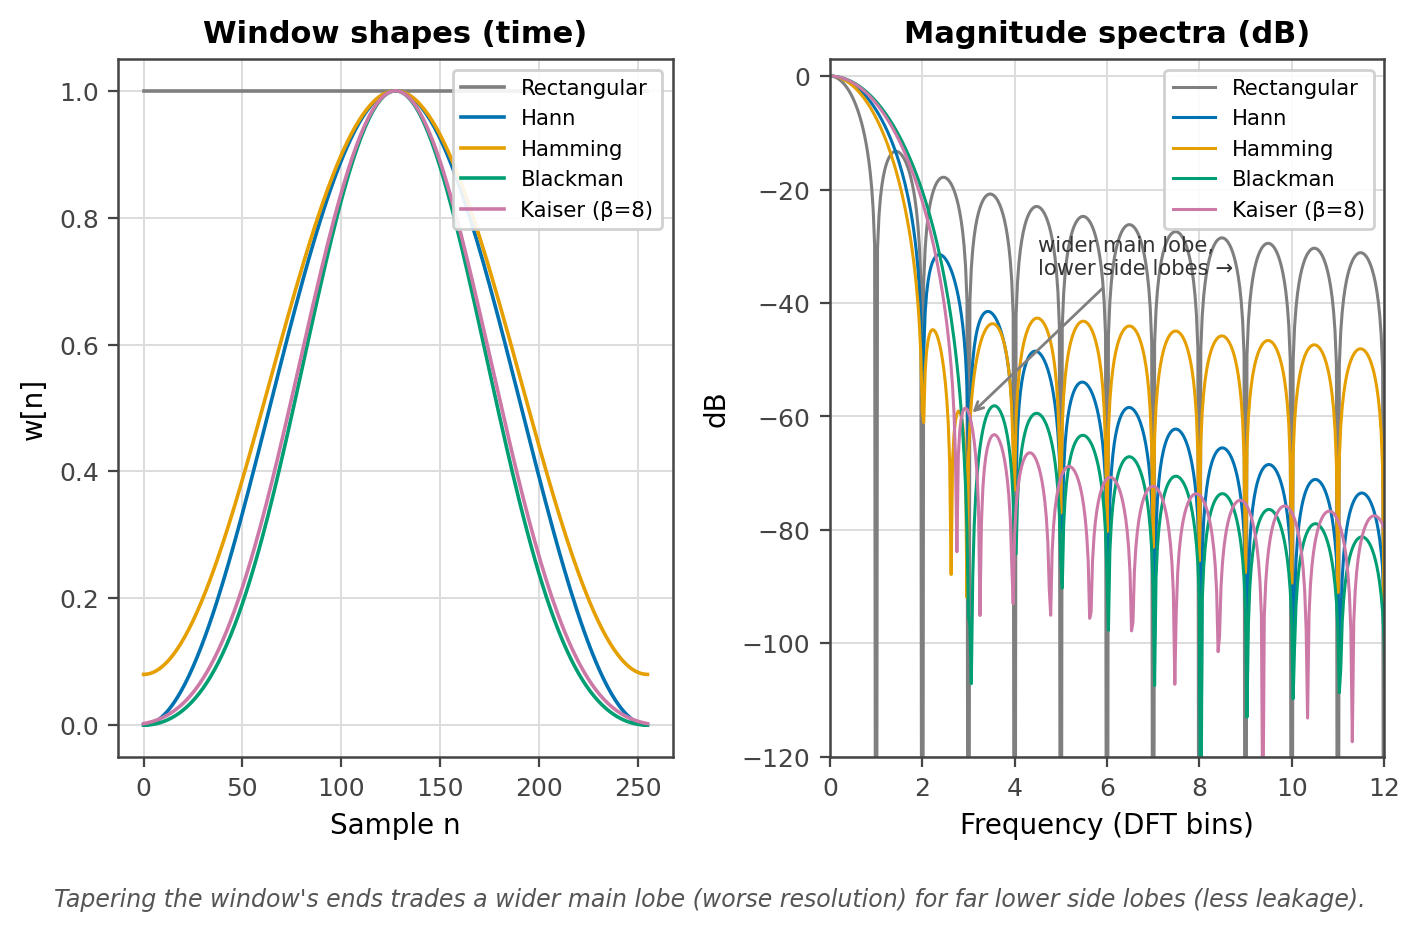

In [3]:
N = 256
windows = [
    ("Rectangular", np.ones(N), bs.C["grey"]),
    ("Hann", np.hanning(N), bs.C["blue"]),
    ("Hamming", np.hamming(N), bs.C["orange"]),
    ("Blackman", np.blackman(N), bs.C["green"]),
    ("Kaiser (β=8)", np.kaiser(N, 8), bs.C["purple"]),
]
fig, ax = bs.newfig(w=7.2, h=4.4, ncols=2)
n = np.arange(N)
for name, w, c in windows:
    ax[0].plot(n, w, color=c, lw=1.3, label=name)
ax[0].set_title("Window shapes (time)")
ax[0].set_xlabel("Sample n")
ax[0].set_ylabel("w[n]")
ax[0].legend(fontsize=7.6, loc="upper right")

Nfft = 8192
for name, w, c in windows:
    W = np.abs(np.fft.rfft(w, Nfft))
    W = 20 * np.log10(W / W.max() + 1e-12)
    fbin = np.fft.rfftfreq(Nfft, 1.0) * N   # in units of DFT bins
    ax[1].plot(fbin, W, color=c, lw=1.1, label=name)
ax[1].set_xlim(0, 12)
ax[1].set_ylim(-120, 3)
ax[1].set_title("Magnitude spectra (dB)")
ax[1].set_xlabel("Frequency (DFT bins)")
ax[1].set_ylabel("dB")
ax[1].legend(fontsize=7.6, loc="upper right")
ax[1].annotate("wider main lobe,\nlower side lobes →", xy=(3, -60),
               xytext=(4.5, -35), fontsize=7.6, color="#333333",
               arrowprops=dict(arrowstyle="->", color=bs.C["grey"]))
bs.takeaway(fig, "Tapering the window's ends trades a wider main lobe "
                 "(worse resolution) for far lower side lobes (less leakage).")
plt.tight_layout()
plt.show()

## 4.2  leakage

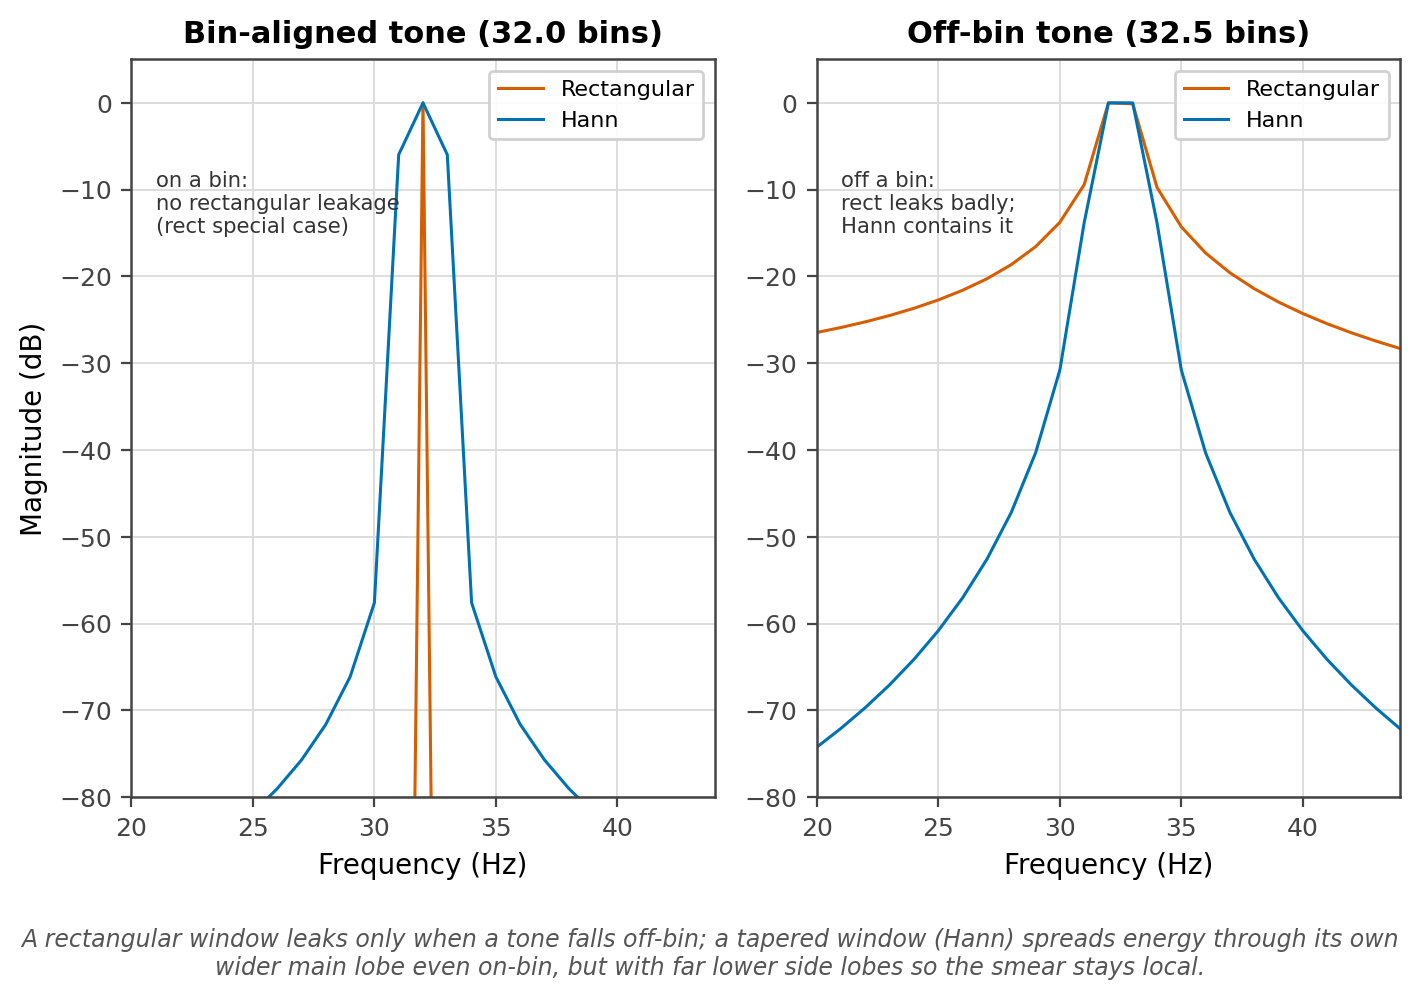

In [4]:
fs = 256.0
N = 256
t = np.arange(N) / fs
df = fs / N   # bin spacing = 1 Hz
# bin-aligned: exactly k*df ; off-bin: half a bin higher
f_aligned = 32 * df       # 32 Hz, exactly on a bin
f_offbin = 32.5 * df      # between bins -> maximal leakage
fig, ax = bs.newfig(w=7.2, h=4.6, ncols=2)

for a, (f0, title) in zip(ax, [(f_aligned, "Bin-aligned tone (32.0 bins)"),
                                (f_offbin, "Off-bin tone (32.5 bins)")]):
    x = np.sin(2 * np.pi * f0 * t)
    for win, name, c in [(np.ones(N), "Rectangular", bs.C["red"]),
                         (np.hanning(N), "Hann", bs.C["blue"])]:
        X = np.abs(np.fft.rfft(x * win))
        X = 20 * np.log10(X / X.max() + 1e-12)
        fb = np.fft.rfftfreq(N, 1 / fs)
        a.plot(fb, X, color=c, lw=1.1, label=name)
    a.set_xlim(20, 44)
    a.set_ylim(-80, 5)
    a.set_title(title)
    a.set_xlabel("Frequency (Hz)")
    a.legend(fontsize=8, loc="upper right")
ax[0].set_ylabel("Magnitude (dB)")
ax[0].text(21, -15, "on a bin:\nno rectangular leakage\n(rect special case)", fontsize=7.6,
           color="#333333")
ax[1].text(21, -15, "off a bin:\nrect leaks badly;\nHann contains it",
           fontsize=7.6, color="#333333")
bs.takeaway(fig, "A rectangular window leaks only when a tone falls off-bin; a tapered "
                 "window (Hann) spreads energy through its own wider main lobe even on-bin, "
                 "but with far lower side lobes so the smear stays local.")
plt.tight_layout()
plt.show()

## 4.3  two tones

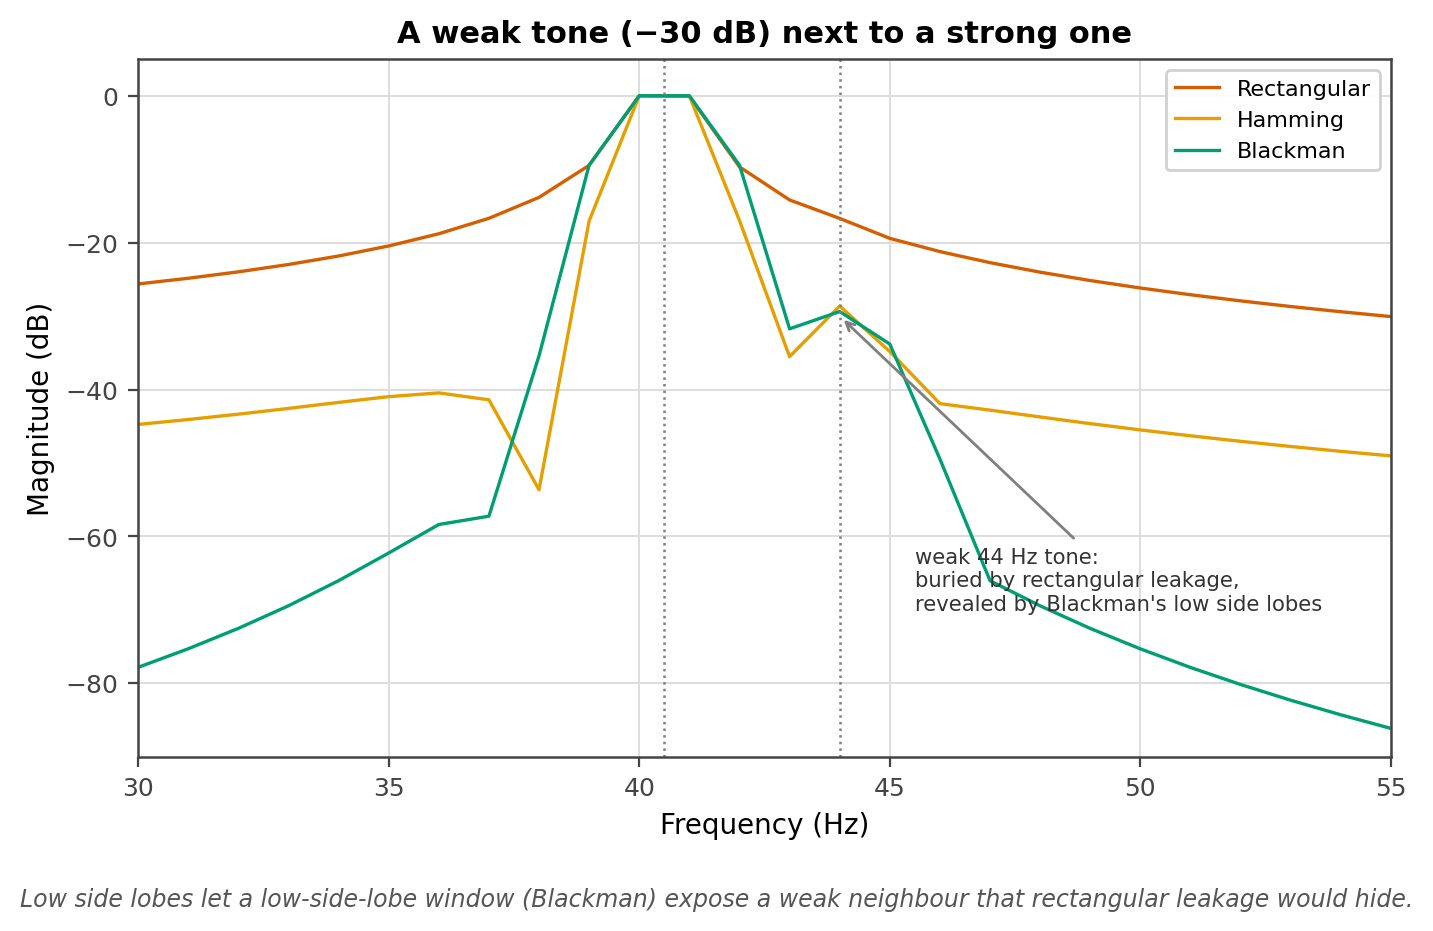

In [5]:
fs = 256.0
N = 256
t = np.arange(N) / fs
# Strong tone deliberately OFF-bin (40.5 Hz) so its rectangular side lobes
# actually spread and bury the weak neighbour. (On-bin, e.g. 40.0 Hz, the sinc
# zeros fall on every other bin and rectangular shows no leakage at all — then
# the caption's story fails.) The weak tone stays on-bin at 44 Hz.
f1, f2 = 40.5, 44.0
x = np.sin(2 * np.pi * f1 * t) + 0.03 * np.sin(2 * np.pi * f2 * t)  # -30 dB
fig, ax = bs.newfig(w=7.2, h=4.4)
for win, name, c in [(np.ones(N), "Rectangular", bs.C["red"]),
                     (np.hamming(N), "Hamming", bs.C["orange"]),
                     (np.blackman(N), "Blackman", bs.C["green"])]:
    X = np.abs(np.fft.rfft(x * win))
    X = 20 * np.log10(X / X.max() + 1e-12)
    fb = np.fft.rfftfreq(N, 1 / fs)
    ax.plot(fb, X, color=c, lw=1.2, label=name)
ax.axvline(f1, color=bs.C["grey"], ls=":", lw=0.9)
ax.axvline(f2, color=bs.C["grey"], ls=":", lw=0.9)
ax.set_xlim(30, 55)
ax.set_ylim(-90, 5)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("A weak tone (−30 dB) next to a strong one")
ax.legend(fontsize=8, loc="upper right")
ax.annotate("weak 44 Hz tone:\nburied by rectangular leakage,\nrevealed by "
            "Blackman's low side lobes", xy=(44, -30), xytext=(45.5, -70),
            fontsize=7.6, color="#333333",
            arrowprops=dict(arrowstyle="->", color=bs.C["grey"]))
bs.takeaway(fig, "Low side lobes let a low-side-lobe window (Blackman) expose "
                 "a weak neighbour that rectangular leakage would hide.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above and the numbers below *exactly* — the cell below **asserts** them with `expect_close`, so a broken environment is flagged rather than failing silently.

In [6]:
from bsp.metrics import (alias_frequency, quantization_snr_db, sqrtN_gain_db,
                         snr_db, cohens_kappa, macro_f1)
from bsp.notebook_checks import expect_close, expected_output_table
from IPython.display import Markdown, display
_rows = []
_rows.append(expect_close('Hann coherent gain (mean of window)', float(np.mean(np.hanning(256))), 0.498, 0.02, 'abs'))
_rows.append(expect_close('Hann ENBW (bins)', float(256*np.sum(np.hanning(256)**2)/np.sum(np.hanning(256))**2), 1.5, 0.05, 'abs'))
display(Markdown(expected_output_table(_rows)))

[PASS] Hann coherent gain (mean of window): got 0.498, expected 0.498 (abs)
[PASS] Hann ENBW (bins): got 1.506, expected 1.5 (abs)


| Quantity | Got | Expected | Status |
|---|---:|---:|:--:|
| Hann coherent gain (mean of window) | 0.498 | 0.498 | ✅ |
| Hann ENBW (bins) | 1.506 | 1.5 | ✅ |

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `w = hann(N)`; `X = fft(x.*w)`; compare with `rectwin`, `kaiser`.

## Sweep and defend — resolution ↔ leakage (which window?)

There is **no single best window**. A stronger taper *lowers side lobes* (less leakage) but *widens the main lobe* (worse resolution) — you cannot minimise both. The cell **measures** the two for four windows so you can see the trade rather than take it on faith.

**Spec to design against:** you must (a) resolve two tones ~2 bins apart *and* (b) see a weak tone ~40 dB below a strong neighbour. **Defend it:** which window meets *both*? If none does, which requirement do you relax, and which window would you pick if only (a) mattered? Finally, name a window that would be *wrong* for (b), and say why.

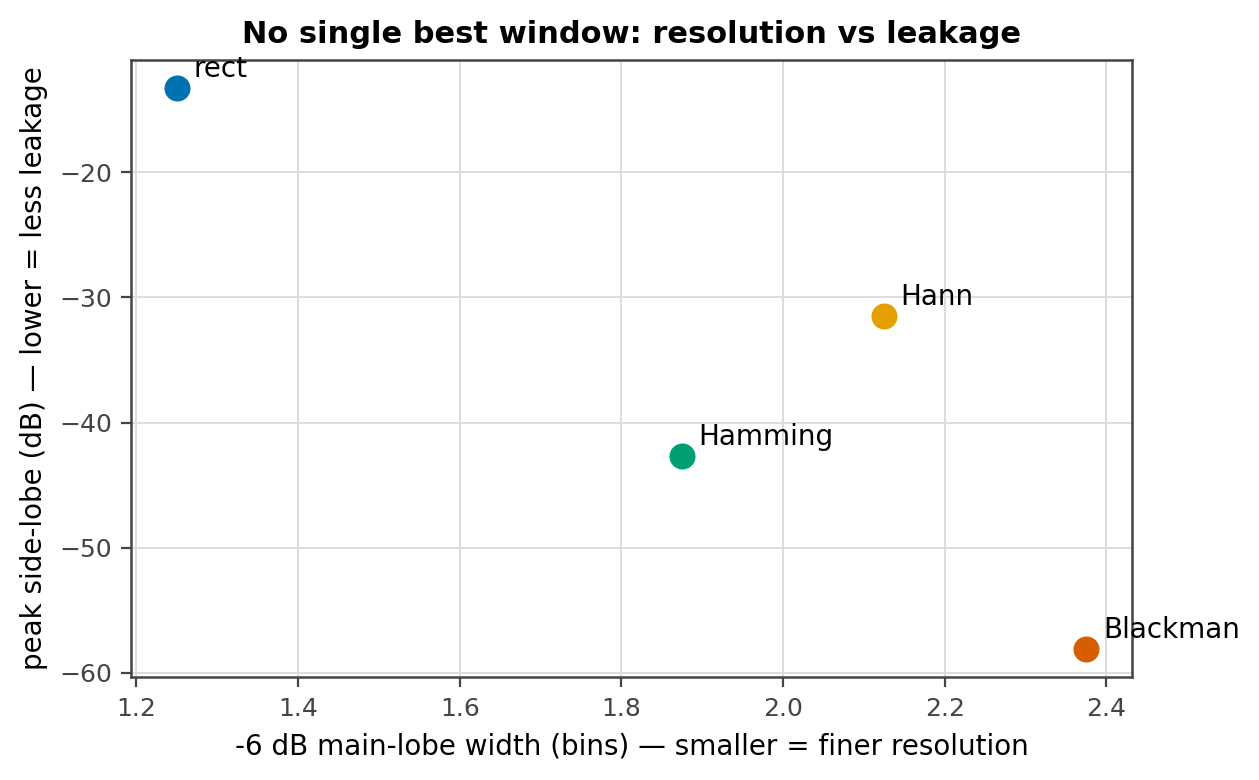

windows              : ['rect', 'Hann', 'Hamming', 'Blackman']
-6dB main-lobe (bins): [np.float64(1.25), np.float64(2.12), np.float64(1.88), np.float64(2.38)]
side-lobe (dB)  : [-13.3, -31.5, -42.7, -58.1]


In [7]:
import numpy as np, matplotlib.pyplot as plt
N, OS = 512, 16
wins = {'rect': np.ones(N), 'Hann': np.hanning(N), 'Hamming': np.hamming(N), 'Blackman': np.blackman(N)}
mlw, sll = [], []
for w in wins.values():
    W = np.abs(np.fft.rfft(w, OS * N)); W /= W.max(); WdB = 20*np.log10(W + 1e-12)
    mlw.append(2 * np.where(WdB < -6)[0][0] / OS)             # -6 dB main-lobe width (bins)
    nulls = np.where(np.diff(np.sign(np.diff(WdB))) > 0)[0]   # local minima = nulls
    sll.append(float(WdB[nulls[0]+1:].max()) if len(nulls) else -120.0)
fig, ax = plt.subplots(figsize=(6.4, 4))
for nm, x, ylv in zip(wins, mlw, sll):
    ax.scatter(x, ylv, s=70); ax.annotate(nm, (x, ylv), xytext=(6, 4), textcoords='offset points')
ax.set_xlabel('-6 dB main-lobe width (bins) — smaller = finer resolution')
ax.set_ylabel('peak side-lobe (dB) — lower = less leakage')
ax.set_title('No single best window: resolution vs leakage'); plt.tight_layout(); plt.show()
print('windows              :', list(wins))
print('-6dB main-lobe (bins):', [round(m, 2) for m in mlw])
print('side-lobe (dB)  :', [round(s, 1) for s in sll])

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Sweep the Kaiser β and watch the main-lobe/side-lobe trade move.

<details><summary>💡 Hint &amp; what you should see</summary>

Larger β → lower side-lobes (**less leakage**) but a wider main-lobe (**worse resolution**). You cannot win both — watch the side-lobe floor drop as the central peak fattens.

</details>

**2.** How does the window choice change measured sigma/spindle band power?

<details><summary>💡 Hint &amp; what you should see</summary>

A leaky window (rect) lets strong neighbours spill into the spindle band and **inflate** its power; a Hann/Kaiser window suppresses that. Expect the measured band power to shift noticeably with the window.

</details>

In [8]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch04_figures.py`.*